# Critical Potts entanglement-spectrum flow

This notebook calculates the half-chain entanglement spectrum of the critical three-state Potts chain for several system sizes and selected boundary conditions. Its main figure follows the numerical plotting convention used for the Potts data in Figure 5 of A. M. Läuchli, *Operator content of real-space entanglement spectra at conformal critical points*.

Only finite-size scatter points are shown.

## 0. Imports

In [129]:
from pathlib import Path
from html import escape
import os
import sys
import time

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
import tenpy
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS


def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "potts_model_project", cwd.parent, cwd.parent / "potts_model_project"]
    for candidate in candidates:
        if (candidate / "potts_model" / "potts.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the potts_model_project folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from potts_model import PottsChain

print("Project root:", PROJECT_ROOT)
print("TeNPy version:", tenpy.__version__)

Project root: /Users/Aditya/Desktop/Third Year Summer Project/potts_model_project
TeNPy version: 1.1.0


## 1. Definitions and Scaling

For a bipartition into regions $A$ and $B$, write the Schmidt decomposition as

$$
|\psi\rangle=\sum_\alpha s_\alpha |\alpha_A\rangle|\alpha_B\rangle.
$$

Here $s_\alpha$ is a **Schmidt value**. The corresponding eigenvalue of the reduced density matrix $\rho_A$ is

$$
\lambda_\alpha=s_\alpha^2,
$$

and this notebook defines the entanglement energy as

$$
\xi_\alpha=-\ln\lambda_\alpha=-2\ln s_\alpha.
$$

Thus, throughout this notebook, $\lambda$ means a reduced-density-matrix eigenvalue, **not** a Schmidt value.

For every boundary condition and every length $L$, sort the levels with multiplicity,

$$
\xi_0(L)\leq\xi_1(L)\leq\xi_2(L)\leq\cdots,
$$

then shift and rescale them as

$$
\widetilde\xi_n(L)=2\,\frac{\xi_n(L)-\xi_0(L)}{\xi_5(L)-\xi_0(L)}.
$$

For the free-boundary Potts spectrum, the expected first four **distinct level groups** are $0$, $2/3$, $5/3$, and $2$, with low-level multiplicities $1$, $2$, $2$, and $1$. The fourth distinct group is therefore the sixth sorted eigenvalue when multiplicity is counted, namely the zero-based entry $\xi_5$. Setting $\xi_5$ to 2 reproduces the normalization used for the three-state Potts spectra in Figure 5. A shift is necessary because the absolute entanglement-energy offset is non-universal; fixing one nonzero gap removes the remaining non-universal overall scale and allows spectra at different $L$ to be compared.

In the antiferromagnetic regime a different scaling has to be chosen but we cannot know what scaling to use before obtaining the data.

The horizontal coordinate is

$$
x_L=\frac{1}{\ln L}.
$$

Boundary-CFT arguments imply that the low entanglement gaps close approximately as $1/\ln L$, which is why the paper uses this variable. The thermodynamic limit would lie at $x_L=0$, but this notebook does not extrapolate to it.

## 2. Numerical parameters

In [130]:

L_values = [20, 50, 100, 150]
chi_max_values = [40, 100, 200, 400]
max_sweeps = 60

J = -1.0
h = -1.0
svd_min = 1e-11
max_E_err = 1e-9

n_levels_to_store = 40
n_levels_to_plot = 24
reference_rank = 5       # sixth eigenvalue = fourth distinct Potts level group
reference_value = 2.0

if any(L % 2 for L in L_values):
    raise ValueError("All L_values must be even for an equal half-chain cut.")
if any(L < 4 for L in L_values):
    raise ValueError("Every entry in L_values must be an integer of at least 4.")
if len(chi_max_values) != len(L_values):
    raise ValueError("chi_max_values must have the same length as L_values.")
if any(chi <= 0 for chi in chi_max_values):
    raise ValueError("Every entry in chi_max_values must be positive.")

run_configs = list(zip(L_values, chi_max_values))
if len(set(run_configs)) != len(run_configs):
    raise ValueError("Each (L, chi_max) pair must be unique.")
if n_levels_to_store <= reference_rank:
    raise ValueError("n_levels_to_store must include the reference level.")

print("Runs (L, chi_max):", run_configs)
print("J = h =", J)
print("max_sweeps:", max_sweeps)

Runs (L, chi_max): [(20, 40), (50, 100), (100, 200), (150, 400)]
J = h = -1.0
max_sweeps: 60


## 3. Boundary-condition selection

The reusable `PottsChain` accepts `1`, `2`, or `3` for a fixed edge; `-1`, `-2`, or `-3` for an edge that forbids that state; and `"free"` for a free edge. Edit only `selected_case_labels` to compare a different subset.

For the periodic case, `order="default"` is intentional. The central MPS cut must divide the physical ring into the two contiguous half-chains used in the paper. A folded MPS order makes the Hamiltonian cheaper but changes which physical sites lie on each side of the central MPS cut.

In [131]:
all_boundary_cases = {
    "free|free": {"left": "free", "right": "free"},
    "1|1": {"left": 1, "right": 1},
    "1|2": {"left": 1, "right": 2},
    "1|3": {"left": 1, "right": 3},
    "1|-1": {"left": 1, "right": -1},
    "1|-2": {"left": 1, "right": -2},
    "1|free": {"left": 1, "right": "free"},
    "-1|-1": {"left": -1, "right": -1},
    "-1|-2": {"left": -1, "right": -2},
    "-1|free": {"left": -1, "right": "free"},
    "periodic": {
        "left": "free",
        "right": "free",
        "periodic": True,
        "order": "default",
    },
}

selected_case_labels = ["free|free"]

unknown_labels = set(selected_case_labels) - set(all_boundary_cases)
if unknown_labels:
    raise KeyError(f"Unknown boundary labels: {sorted(unknown_labels)}")

boundary_cases = {
    label: all_boundary_cases[label]
    for label in selected_case_labels
}

boundary_cases

{'free|free': {'left': 'free', 'right': 'free'}}

## 4. Entanglement-spectrum helpers

TeNPy's direct entanglement spectrum is checked against $-2\ln s_\alpha$ from the central Schmidt values. The code also verifies that the density-matrix weights sum to one and that they reconstruct the central von Neumann entropy.

In [132]:
def central_entanglement_spectrum(psi):
    """Return all finite xi=-log(lambda) values at the equal half-chain cut."""
    if psi.L % 2:
        raise ValueError("Use an even L for an equal half-chain cut.")
    cut = psi.L // 2 - 1
    xi = np.asarray(psi.entanglement_spectrum()[cut], dtype=float)
    return np.sort(xi[np.isfinite(xi)])


def central_spectrum_from_schmidt_values(psi):
    """Independently calculate xi=-2 log(s) from central Schmidt values."""
    s = np.asarray(psi.get_SL(psi.L // 2), dtype=float)
    s = s[np.isfinite(s) & (s > 0.0)]
    return np.sort(-2.0 * np.log(s))


def normalize_spectrum(xi, rank, target=reference_value):
    """Shift xi[0] to zero and set xi[rank] to target."""
    xi = np.sort(np.asarray(xi, dtype=float))
    if len(xi) <= rank:
        raise ValueError(f"Need at least {rank + 1} levels for this normalization.")
    gap = xi[rank] - xi[0]
    if not np.isfinite(gap) or gap <= 1e-12:
        raise ValueError("The selected reference gap is zero or numerically unstable.")
    return target * (xi - xi[0]) / gap


def validate_central_spectrum(psi, xi, atol=2e-10):
    xi_from_s = central_spectrum_from_schmidt_values(psi)
    if len(xi) != len(xi_from_s) or not np.allclose(xi, xi_from_s, atol=atol, rtol=atol):
        raise RuntimeError("TeNPy's direct spectrum disagrees with -2 log(Schmidt values).")

    lambdas = np.exp(-xi)
    lambda_sum = float(np.sum(lambdas))
    entropy_from_spectrum = float(np.sum(lambdas * xi))
    central_entropy = float(psi.entanglement_entropy()[psi.L // 2 - 1])

    if not np.isclose(lambda_sum, 1.0, atol=2e-10, rtol=2e-10):
        raise RuntimeError(f"Central density-matrix eigenvalues sum to {lambda_sum}, not 1.")
    if not np.isclose(entropy_from_spectrum, central_entropy, atol=2e-10, rtol=2e-10):
        raise RuntimeError("The spectrum does not reconstruct the central entropy.")

    return {
        "lambda_sum": lambda_sum,
        "entropy_from_spectrum": entropy_from_spectrum,
        "central_entropy": central_entropy,
    }

## 5. Model builder and DMRG runner

The Hamiltonian uses the reusable project convention with $J=h=1$, the ferromagnetic critical point. The spectrum is taken at the cut between physical sites $L/2-1$ and $L/2$. For the periodic chain this produces a contiguous interval of length $L/2$ with two entanglement boundaries.

In [133]:
class DMRGProgressBar:
    """In-place Jupyter progress display updated at TeNPy sweep checkpoints."""

    def __init__(self, label, L, chi_max, configured_max_sweeps, width=28):
        self.label = label
        self.L = L
        self.chi_max = chi_max
        self.configured_max_sweeps = configured_max_sweeps
        # TeNPy 1.1.0 checks its stopping condition after sweeps > max_sweeps.
        self.total_sweeps = configured_max_sweeps + 1
        self.width = width
        self.start_time = time.perf_counter()
        self.handle = display(self._render(0, 1, "starting"), display_id=True)

    def _render(self, sweeps, achieved_chi, status):
        fraction = min(max(sweeps / self.total_sweeps, 0.0), 1.0)
        filled = round(self.width * fraction)
        bar = "█" * filled + "░" * (self.width - filled)
        elapsed = time.perf_counter() - self.start_time
        text = (
            f"{self.label} | L={self.L} | chi_max={self.chi_max} | "
            f"sweep {sweeps}/{self.total_sweeps} [{bar}] {100 * fraction:5.1f}% | "
            f"current chi={achieved_chi} | {elapsed:,.1f} s | {status}"
        )
        return HTML(f"<pre style='margin:0.25em 0'>{escape(text)}</pre>")

    def update(self, engine, status="running"):
        achieved_chi = max(engine.psi.chi) if len(engine.psi.chi) else 1
        rendered = self._render(engine.sweeps, achieved_chi, status)
        if self.handle is None:
            print(rendered.data, flush=True)
        else:
            self.handle.update(rendered)

    def at_checkpoint(self, engine):
        self.update(engine)


def build_model(L, case):
    return PottsChain.from_parameters(
        L=L,
        J=J,
        h=h,
        left_boundary=case["left"],
        right_boundary=case["right"],
        periodic=case.get("periodic", False),
        order=case.get("order", "default"),
    )


def run_dmrg_for_case(L, chi_for_L, label, case):
    model = build_model(L, case)
    if J>0:
        initial_state = model.initial_product_state(bulk_state=1)
    else:
        initial_state = ["1" if i % 2 == 0 else "2" for i in range(model.lat.N_sites)]
    psi = MPS.from_product_state(
        model.lat.mps_sites(),
        initial_state,
        bc=model.lat.bc_MPS,
        unit_cell_width=model.lat.mps_unit_cell_width,
    )

    dmrg_params = {
        "mixer": True,
        "max_sweeps": max_sweeps,
        "N_sweeps_check": 1,
        "max_E_err": max_E_err,
        "max_N_sites_per_ring": model.lat.N_sites,
        "trunc_params": {
            "chi_max": chi_for_L,
            "svd_min": svd_min,
        },
    }

    engine = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
    progress = DMRGProgressBar(label, L, chi_for_L, max_sweeps)
    engine.checkpoint.connect(progress.at_checkpoint)
    try:
        energy, psi = engine.run()
    except Exception:
        progress.update(engine, status="failed")
        raise

    if engine.shelve:
        final_status = "stopped at time limit"
    elif engine.is_converged():
        final_status = "converged"
    else:
        final_status = "sweep limit reached"
    progress.update(engine, status=final_status)

    xi_all = central_entanglement_spectrum(psi)
    checks = validate_central_spectrum(psi, xi_all)
    xi = xi_all[:n_levels_to_store]

    return {
        "label": label,
        "case": case,
        "L": L,
        "chi_max_requested": chi_for_L,
        "model": model,
        "psi": psi,
        "energy": float(np.real(energy)),
        "energy_per_site": float(np.real(energy) / L),
        "xi_raw": xi,
        "xi_shifted": xi - xi[0],
        "xi_scaled": normalize_spectrum(
            xi,
            rank=reference_rank,
            target=reference_value,
        ),
        "x_inv_log_L": 1.0 / np.log(L),
        "checks": checks,
        "chi": list(psi.chi),
    }

## 6. Run all selected cases

This is the expensive cell. Each entry of `chi_max_values` is paired with the entry at the same position in `L_values`. A run is identified by its `(L, chi_max)` pair, so the same system size may appear more than once with different bond dimensions. Runtime grows with the number of boundary cases, the system sizes, the selected bond dimensions, and `max_sweeps`.

The in-place bar updates after each completed sweep and reports the current achieved bond dimension and elapsed time. It measures sweep progress rather than estimated wall-clock progress. TeNPy 1.1.0 tests its stopping condition after `sweeps > max_sweeps`, so an unconverged run can complete and display `max_sweeps + 1` sweeps.

In [134]:
results = {label: {} for label in selected_case_labels}

for label, case in boundary_cases.items():
    for L, chi_for_L in run_configs:
        print(f"Running {label:>10}, L={L:>3}, chi_max={chi_for_L} ...", flush=True)
        result = run_dmrg_for_case(L, chi_for_L, label, case)
        results[label][(L, chi_for_L)] = result
        print(
            f"  E/L={result['energy_per_site']:.10f}, "
            f"max chi={max(result['chi'])}, "
            f"sum(lambda)={result['checks']['lambda_sum']:.12f}"
        )

print("Done.")

Running  free|free, L= 20, chi_max=40 ...


  E/L=-0.5938128317, max chi=40, sum(lambda)=1.000000000000
Running  free|free, L= 50, chi_max=100 ...


  E/L=-0.6007066272, max chi=100, sum(lambda)=1.000000000000
Running  free|free, L=100, chi_max=200 ...


  E/L=-0.6030263581, max chi=200, sum(lambda)=1.000000000000
Running  free|free, L=150, chi_max=400 ...


  E/L=-0.6038020755, max chi=400, sum(lambda)=1.000000000000
Done.


## 7. Numerical diagnostics

These checks establish internal consistency, not convergence in $L$ or bond dimension. In particular, a successful row does not mean that its higher entanglement levels are quantitatively converged.

In [142]:
print(
    f"{'boundary':>10} {'L':>4} {'chi cap':>8} {'E/L':>15} {'max chi':>9} "
    f"{'sum(lambda)':>14} {'S spectrum - S TeNPy':>22}"
)
print("-" * 91)

for label in selected_case_labels:
    for L, chi_for_L in run_configs:
        result = results[label][(L, chi_for_L)]
        checks = result["checks"]
        entropy_difference = checks["entropy_from_spectrum"] - checks["central_entropy"]
        print(
            f"{label:>10} {L:4d} {chi_for_L:8d} {result['energy_per_site']:15.10f} "
            f"{max(result['chi']):9d} {checks['lambda_sum']:14.11f} "
            f"{entropy_difference:22.3e}"
        )

  boundary    L  chi cap             E/L   max chi    sum(lambda)   S spectrum - S TeNPy
-------------------------------------------------------------------------------------------
 free|free   20       40   -0.5938128317        40  1.00000000000             -1.110e-16
 free|free   50      100   -0.6007066272       100  1.00000000000             -2.220e-16
 free|free  100      200   -0.6030263581       200  1.00000000000              0.000e+00
 free|free  150      400   -0.6038020755       400  1.00000000000             -2.220e-16


## 8. Separate the even and odd entanglement cuts

For a cut at MPS bond `b`, the left subsystem contains sites $0,\ldots,b-1$, so its size is $b$. In the antiferromagnetic chain the correlations are staggered, and the Schmidt spectrum depends strongly on whether this cut size is even or odd. In particular, our odd-cut spectra have a nearly degenerate lowest pair, while the even-cut spectra have a single lowest level followed by a nearly degenerate pair. Mixing these two sectors in one finite-size plot creates alternating branches and can make a normalization denominator artificially tiny.

For every saved DMRG state, the code below extracts **both** parities. It uses the exact half-chain cut when $L/2$ has the requested parity and otherwise uses the immediately adjacent cut at $L/2-1$. Thus each plot contains every system size, and the off-centre subsystem differs from half the chain by only one site. This reads Schmidt values already stored in each MPS; it does not rerun DMRG. The printed raw gaps should always be inspected before interpreting either scaled plot.


For h=-1, J=-1, the towers seem to be:
even: 0,1,1,3,4,4, ...
odd: 0,0,2,2,3,3, ...

In [148]:
def spectrum_at_cut(psi, cut, number_to_store=n_levels_to_store):
    """Return xi=-2 log(s) at an existing MPS bond; no DMRG is performed."""
    if not 1 <= cut < psi.L:
        raise ValueError(f"Cut {cut} is outside the internal bonds of an L={psi.L} MPS.")
    s = np.asarray(psi.get_SL(cut), dtype=float)
    s = s[np.isfinite(s) & (s > 0.0)]
    return np.sort(-2.0 * np.log(s))[:number_to_store]


def nearest_central_cut(L, parity):
    """Choose L//2 if possible, otherwise the adjacent cut to its left."""
    centre = L // 2
    return centre if centre % 2 == parity else centre - 1


ordered_runs = sorted(run_configs, key=lambda config: (config[0], config[1]))
cut_spectra = {
    "even": {label: {} for label in selected_case_labels},
    "odd": {label: {} for label in selected_case_labels},
}

for label in selected_case_labels:
    for config in ordered_runs:
        result = results[label][config]
        for cut_name, parity in (("even", 0), ("odd", 1)):
            cut = nearest_central_cut(result["L"], parity)
            xi = spectrum_at_cut(result["psi"], cut)
            cut_spectra[cut_name][label][config] = {
                "cut": cut,
                "xi_raw": xi,
                "xi_shifted": xi - xi[0],
                "x_inv_log_L": result["x_inv_log_L"],
                "L": result["L"],
                "chi_max_requested": result["chi_max_requested"],
            }

        even = cut_spectra["even"][label][config]
        odd = cut_spectra["odd"][label][config]
        print(
            f"{label:>10}  L={result['L']:>3}, chi={result['chi_max_requested']:>4}  "
            f"even cut b={even['cut']:>3}: "
            f"{np.array2string(even['xi_shifted'][:6], precision=8)}  |  "
            f"odd cut b={odd['cut']:>3}: "
            f"{np.array2string(odd['xi_shifted'][:6], precision=8)}"
        )

 free|free  L= 20, chi=  40  even cut b= 10: [0.         1.38717768 1.38717777 4.31976869 6.02131892 6.02131944]  |  odd cut b=  9: [0.00000000e+00 5.35135342e-06 2.90706306e+00 2.91458084e+00
 4.45609838e+00 4.45609999e+00]
 free|free  L= 50, chi= 100  even cut b= 24: [0.         1.16476448 1.16476451 3.57221868 4.89367349 4.8936736 ]  |  odd cut b= 25: [0.00000000e+00 7.01752134e-06 2.39209423e+00 2.39209423e+00
 3.63858556e+00 3.63858789e+00]
 free|free  L=100, chi= 200  even cut b= 50: [0.         1.03732931 1.03732932 3.16101667 4.2983089  4.2983089 ]  |  odd cut b= 49: [0.00000000e+00 1.25264620e-05 2.11482095e+00 2.11494018e+00
 3.20657679e+00 3.20658096e+00]
 free|free  L=150, chi= 400  even cut b= 74: [0.         0.97500269 0.97500269 2.96332027 4.01704759 4.0170476 ]  |  odd cut b= 75: [0.00000000e+00 1.50007291e-06 1.98127051e+00 1.98127051e+00
 2.99962289e+00 2.99962339e+00]


### Raw unscaled spectra for each cut parity

The following two figures show the shifted entanglement energies $\xi_n-\xi_0$ directly, with **no division by a reference gap**. Even and odd cuts are displayed separately so that their different lowest multiplets are visible rather than mixed together. These plots are the appropriate place to check for tiny splittings, level crossings, and poorly converged higher levels before interpreting the scaled figures. The legend states the actual cut `b` used for each saved MPS.

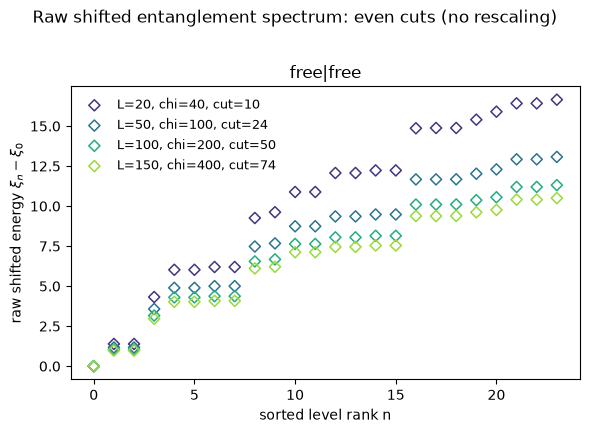

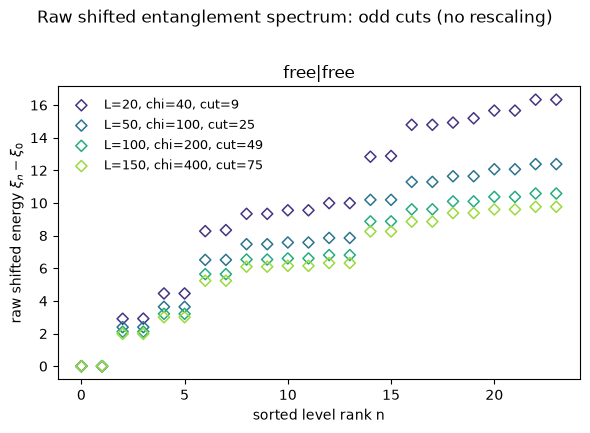

In [149]:
def plot_raw_spectra_for_cut(cut_name):
    fig, axes = plt.subplots(
        1, len(selected_case_labels),
        figsize=(6.0 * len(selected_case_labels), 4.2),
        squeeze=False,
    )
    run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

    for ax, label in zip(axes.ravel(), selected_case_labels):
        for colour, config in zip(run_colours, ordered_runs):
            result = cut_spectra[cut_name][label][config]
            y = result["xi_shifted"][:n_levels_to_plot]
            ax.scatter(
                np.arange(len(y)), y,
                marker="D", s=32,
                facecolors="none", edgecolors=[colour], linewidths=1.1,
                label=(
                    f"L={result['L']}, chi={result['chi_max_requested']}, "
                    f"cut={result['cut']}"
                ),
            )
        ax.set_title(label)
        ax.set_xlabel("sorted level rank n")
        ax.set_ylabel(r"raw shifted energy $\xi_n-\xi_0$")
        ax.legend(frameon=False, fontsize=9)

    fig.suptitle(
        f"Raw shifted entanglement spectrum: {cut_name} cuts (no rescaling)",
        y=1.02,
    )
    fig.tight_layout()
    display(fig)
    plt.close(fig)


plot_raw_spectra_for_cut("even")
plot_raw_spectra_for_cut("odd")

## 9. Even-cut scaling and plot

For the even cuts, the lowest observed structure is one level at zero followed by a nearly degenerate pair $\xi_1\simeq\xi_2$ (for the case h=-1, J=-1). We use the first member of this pair as the reference:

$$
\widetilde\xi_n^{\mathrm{even}}(L)
=\frac{\xi_n-\xi_0}{\xi_1-\xi_0}.
$$

This sets $\widetilde\xi_1=1$; its nearly degenerate partner $\widetilde\xi_2$ should lie close to 1. It uses only the lowest resolved excitation and avoids relying on the higher spectrum. The horizontal coordinate remains $x_L=1/\ln L$. Only points are drawn: ranks are not connected across sizes, and no extrapolated lines are added.

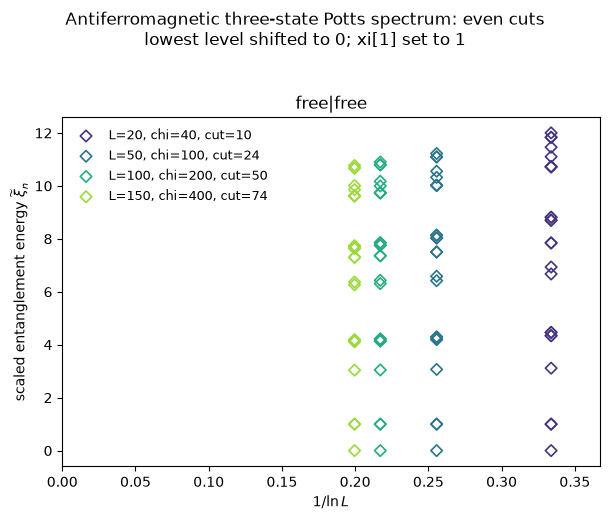

In [146]:
fig, axes = plt.subplots(
    1, len(selected_case_labels),
    figsize=(6.2 * len(selected_case_labels), 5.0),
    sharey=True,
    squeeze=False,
)
run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

for ax, label in zip(axes.ravel(), selected_case_labels):
    available = [cut_spectra["even"][label][config] for config in ordered_runs]

    for colour, result in zip(run_colours, available):
        shifted = result["xi_shifted"]
        if len(shifted) < 2:
            raise ValueError("Even-cut normalization needs at least two levels.")
        reference_gap = shifted[1]
        if not np.isfinite(reference_gap) or reference_gap <= 0.0:
            raise ValueError("Invalid even-cut reference gap.")
        y = (shifted / reference_gap)[:n_levels_to_plot]
        x = np.full(len(y), result["x_inv_log_L"])
        ax.scatter(
            x, y,
            marker="D", s=34,
            facecolors="none", edgecolors=[colour], linewidths=1.2,
            label=(
                f"L={result['L']}, chi={result['chi_max_requested']}, "
                f"cut={result['cut']}"
            ),
        )

    ax.set_xlim(0.0, max(result["x_inv_log_L"] for result in available) * 1.10)
    ax.set_xlabel(r"$1/\ln L$")
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=9)

axes[0, 0].set_ylabel(r"scaled entanglement energy $\widetilde{\xi}_n$")
fig.suptitle(
    "Antiferromagnetic three-state Potts spectrum: even cuts\n"
    "lowest level shifted to 0; xi[1] set to 1",
    y=1.03,
)
fig.tight_layout()

## 10. Odd-cut scaling and plot

For the odd cuts, (for the case h=-1, J=-1) $\xi_0\simeq\xi_1$ is a nearly degenerate lowest pair, so the tiny splitting $\xi_1-\xi_0$ must **not** set the scale. The first clearly nonzero group begins at $\xi_2$, which we set to 2:

$$
\widetilde\xi_n^{\mathrm{odd}}(L)
=2\frac{\xi_n-\xi_0}{\xi_2-\xi_0}.
$$

This keeps the lowest doublet near 0 and sets $\widetilde\xi_2=2$; its nearly degenerate partner $\widetilde\xi_3$ should lie close to 2. As in the even plot, only points are shown and no ranks are connected or extrapolated.

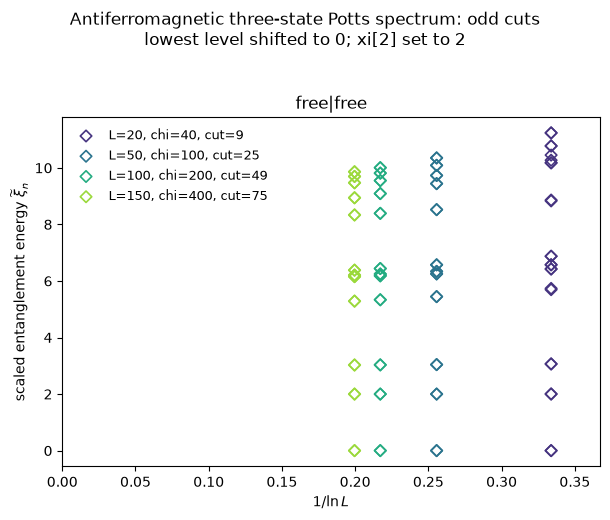

In [147]:
fig, axes = plt.subplots(
    1, len(selected_case_labels),
    figsize=(6.2 * len(selected_case_labels), 5.0),
    sharey=True,
    squeeze=False,
)
run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

for ax, label in zip(axes.ravel(), selected_case_labels):
    available = [cut_spectra["odd"][label][config] for config in ordered_runs]

    for colour, result in zip(run_colours, available):
        shifted = result["xi_shifted"]
        if len(shifted) < 3:
            raise ValueError("Odd-cut normalization needs at least three levels.")
        reference_gap = shifted[2]
        if not np.isfinite(reference_gap) or reference_gap <= 0.0:
            raise ValueError("Invalid odd-cut reference gap.")
        y = (2.0 * shifted / reference_gap)[:n_levels_to_plot]
        x = np.full(len(y), result["x_inv_log_L"])
        ax.scatter(
            x, y,
            marker="D", s=34,
            facecolors="none", edgecolors=[colour], linewidths=1.2,
            label=(
                f"L={result['L']}, chi={result['chi_max_requested']}, "
                f"cut={result['cut']}"
            ),
        )

    ax.set_xlim(0.0, max(result["x_inv_log_L"] for result in available) * 1.10)
    ax.set_xlabel(r"$1/\ln L$")
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=9)

axes[0, 0].set_ylabel(r"scaled entanglement energy $\widetilde{\xi}_n$")
fig.suptitle(
    "Antiferromagnetic three-state Potts spectrum: odd cuts\n"
    "lowest level shifted to 0; xi[2] set to 2",
    y=1.03,
)
fig.tight_layout()

## 11. Interpretation limits

At this stage the plot reveals only coarse finite-size trends. Much more computational power would be needed to be able to extract valuable information.

- Even and odd cuts are normalized separately because they exhibit different low-level multiplicities. These normalizations make each parity sector comparable across $L$; they do not by themselves identify the associated boundary-CFT characters.
- The off-centre cut has subsystem size $L/2-1$ rather than $L/2$. This one-site difference is deliberate: it preserves cut parity across all system sizes and becomes negligible relative to $L$ as the chain grows.
- When applying this notebook to a different coupling or physical boundary condition, inspect the printed raw gaps before assuming that the same reference levels remain appropriate.
- Low-lying levels generally converge before high levels. Increasing `n_levels_to_plot` can therefore display levels that are poorly converged even when the DMRG energy looks stable.